In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('engine_failure_dataset.csv')
df.head(15)


,Time_Stamp,Temperature,RPM,Fuel_Efficiency,Vibration_X,Vibration_Y,Vibration_Z,Torque,Power_Output,Fault_Condition,Operational_Mode
0,2024-12-24 10:00:00,60.308585,3426.827588,20.445472,0.874657,0.005686,0.529798,107.877658,23.367684,2,Idle
1,2024-12-24 10:05:00,112.705055,2949.758424,23.083947,0.696461,0.391779,0.124336,60.351655,57.941022,3,Cruising
2,2024-12-24 10:10:00,108.670976,1817.971040,20.555326,0.495276,0.189714,0.886417,110.986564,47.732998,2,Cruising
3,2024-12-24 10:15:00,107.114691,2730.660539,23.226431,0.986206,0.983202,0.468114,77.416793,44.112039,2,Cruising
4,2024-12-24 10:20:00,118.075814,1854.488677,21.148226,0.710810,0.101139,0.481034,100.475881,80.681972,2,Cruising
5,2024-12-24 10:25:00,78.157210,2324.480476,16.627448,0.484482,0.242013,0.437504,91.495077,86.981820,0,Cruising
6,2024-12-24 10:30:00,114.084534,1128.439288,26.561841,0.261974,0.715318,0.280295,123.156877,82.441668,1,Cruising
7,2024-12-24 10:35:00,108.399936,2424.950038,24.155412,0.432189,0.761122,0.869901,152.349026,80.371809,1,Idle
8,2024-12-24 10:40:00,84.485655,1662.500402,25.535557,0.140342,0.341326,0.172818,90.763384,27.128899,0,Idle
9,2024-12-24 10:45:00,73.573443,2815.996636,28.375972,0.384356,0.034136,0.230663,127.348256,31.823300,1,Heavy Load


In [3]:
df.tail(15)

,Time_Stamp,Temperature,RPM,Fuel_Efficiency,Vibration_X,Vibration_Y,Vibration_Z,Torque,Power_Output,Fault_Condition,Operational_Mode
985,2024-12-27 20:05:00,60.517771,2113.854228,28.822222,0.957763,0.843768,0.245213,117.299679,30.100370,0,Idle
986,2024-12-27 20:10:00,67.382938,1802.863643,16.477748,0.655414,0.031358,0.335237,85.521862,86.451157,2,Idle
987,2024-12-27 20:15:00,108.137974,3118.537526,18.994805,0.508830,0.240114,0.738970,138.125454,34.625515,0,Heavy Load
988,2024-12-27 20:20:00,89.977633,1822.593548,29.363064,0.149270,0.812307,0.017722,161.171448,76.112491,1,Heavy Load
989,2024-12-27 20:25:00,95.927735,1431.233147,17.491845,0.177542,0.412400,0.438397,104.635027,85.410623,0,Cruising
990,2024-12-27 20:30:00,62.719359,1122.048715,23.582175,0.145960,0.406351,0.805187,58.021675,81.925922,2,Idle
991,2024-12-27 20:35:00,97.723170,2936.733198,21.643948,0.510171,0.202600,0.242645,111.864209,83.561183,2,Idle
992,2024-12-27 20:40:00,109.615658,3066.396937,21.159630,0.338780,0.656336,0.843793,77.907419,84.681219,1,Heavy Load
993,2024-12-27 20:45:00,86.830415,3478.573256,23.125066,0.677850,0.736128,0.964644,100.825145,61.622089,1,Heavy Load
994,2024-12-27 20:50:00,105.154064,1171.247065,22.915267,0.183189,0.007102,0.870562,164.030985,82.914248,3,Idle


In [5]:
df = df.drop('Time_Stamp', axis=1)

In [49]:
# Get dimensions
rows = df.shape[0]
attributes = df.shape[1]

print(f"Number of rows: {rows}")
print(f"Number of attributes: {attributes}")
df.shape

Number of rows: 1000
Number of attributes: 10


(1000, 10)

In [50]:
numeric_count = len(df.select_dtypes(include=['number']).columns)

# Count categorical attributes (objects, strings, categories)
categorical_count = len(df.select_dtypes(exclude=['number']).columns)

print(f"Numeric attributes: {numeric_count}")
print(f"Categorical attributes: {categorical_count}")

Numeric attributes: 9
Categorical attributes: 1


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Temperature       1000 non-null   float64
 1   RPM               1000 non-null   float64
 2   Fuel_Efficiency   1000 non-null   float64
 3   Vibration_X       1000 non-null   float64
 4   Vibration_Y       1000 non-null   float64
 5   Vibration_Z       1000 non-null   float64
 6   Torque            1000 non-null   float64
 7   Power_Output      1000 non-null   float64
 8   Fault_Condition   1000 non-null   int64  
 9   Operational_Mode  1000 non-null   object 
dtypes: float64(8), int64(1), object(1)
memory usage: 74.3+ KB


In [52]:
df.describe()

,Temperature,RPM,Fuel_Efficiency,Vibration_X,Vibration_Y,Vibration_Z,Torque,Power_Output,Fault_Condition
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,90.504323,2512.321847,22.490255,0.500771,0.502289,0.483137,123.574345,58.881629,1.465000
std,17.255081,867.543649,4.422922,0.294531,0.281046,0.288449,42.897150,22.535297,1.106345
min,60.013118,1000.737383,15.045726,0.000170,0.000741,0.001086,50.059144,20.148910,0.000000
25%,75.708728,1757.938417,18.634425,0.234537,0.264195,0.233457,85.735962,40.220009,0.000000
50%,90.168595,2498.874857,22.433952,0.519200,0.503314,0.461902,122.377927,58.850054,1.000000
75%,105.478252,3273.470646,26.448111,0.752874,0.744645,0.737903,160.091056,78.345886,2.000000
max,119.982191,3996.039482,29.998912,0.999893,0.999531,0.999384,199.909402,99.932956,3.000000


In [53]:
df.isnull().sum()

Temperature         0
RPM                 0
Fuel_Efficiency     0
Vibration_X         0
Vibration_Y         0
Vibration_Z         0
Torque              0
Power_Output        0
Fault_Condition     0
Operational_Mode    0
dtype: int64

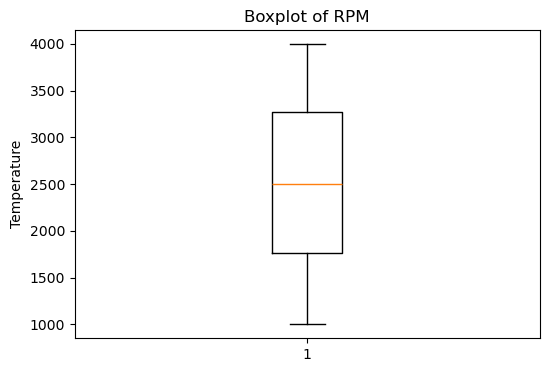

In [8]:
plt.figure(figsize=(6, 4))
plt.boxplot(df['RPM'])

plt.title("Boxplot of RPM")
plt.ylabel("Temperature")
plt.show()

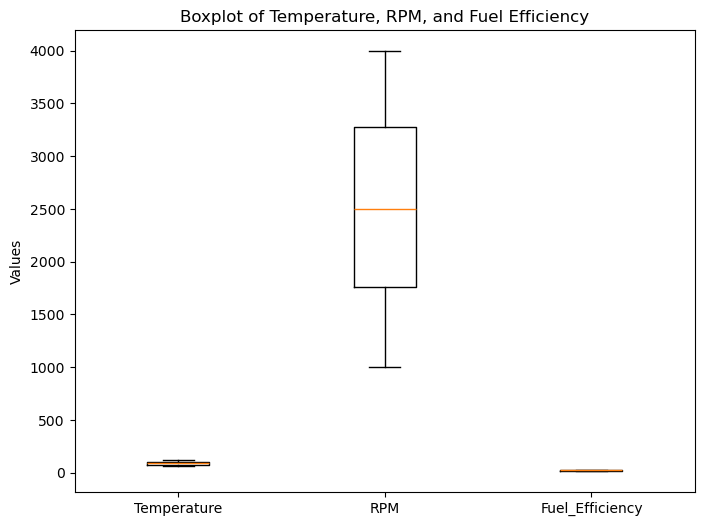

In [9]:
plt.figure(figsize=(8, 6))

plt.boxplot([
    df['Temperature'].dropna(),
    df['RPM'].dropna(),
    df['Fuel_Efficiency'].dropna()
],
labels=['Temperature', 'RPM', 'Fuel_Efficiency'])

# Title and labels
plt.title("Boxplot of Temperature, RPM, and Fuel Efficiency")
plt.ylabel("Values")

plt.show()

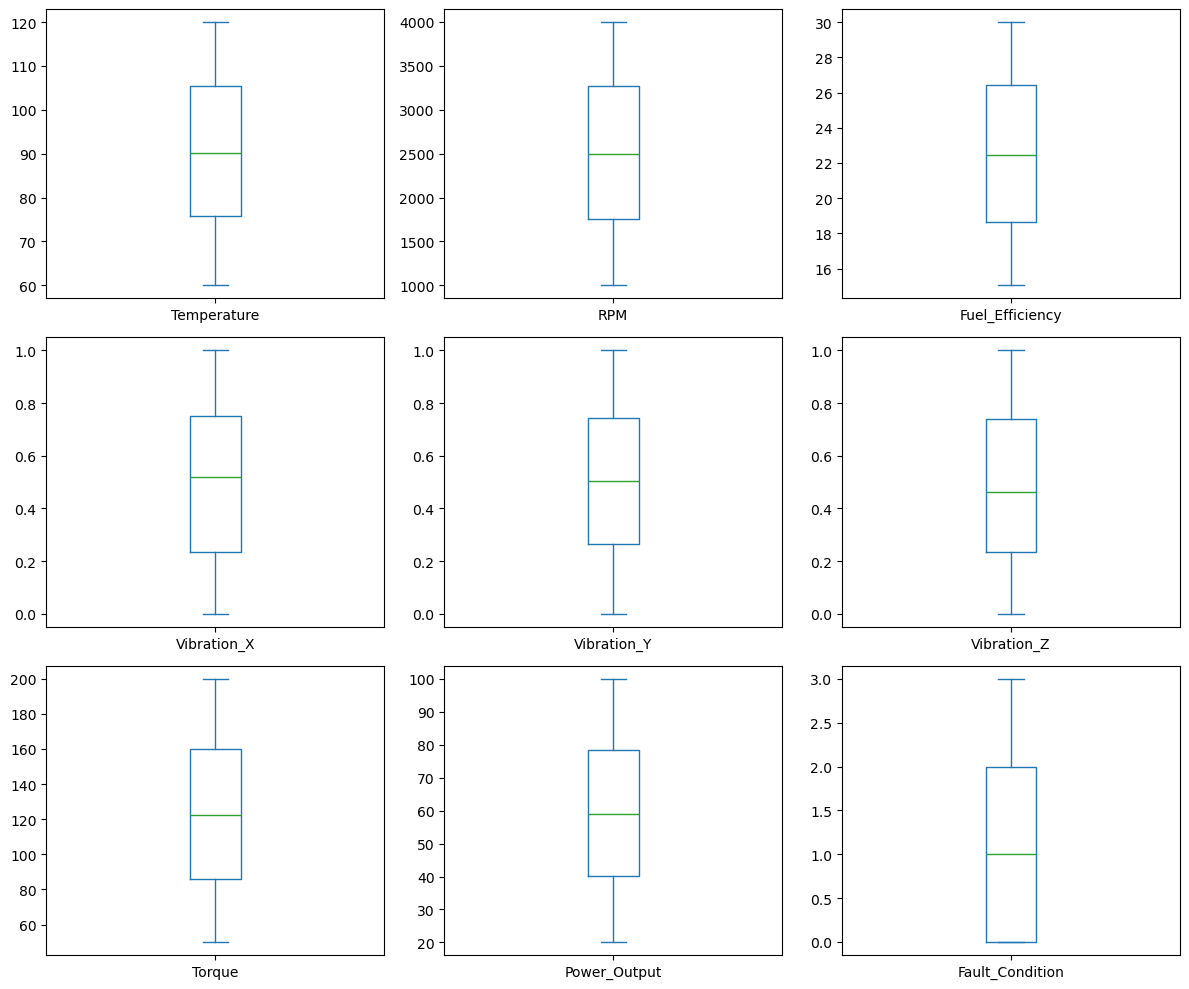

In [11]:
# Univariate Analysis of Dataset
numeric_df = df.select_dtypes(include=['int64', 'float64'])

numeric_df.plot(
    kind='box',
    subplots=True,
    layout=(3, 3),
    figsize=(12, 10)
)

plt.tight_layout()
plt.show()

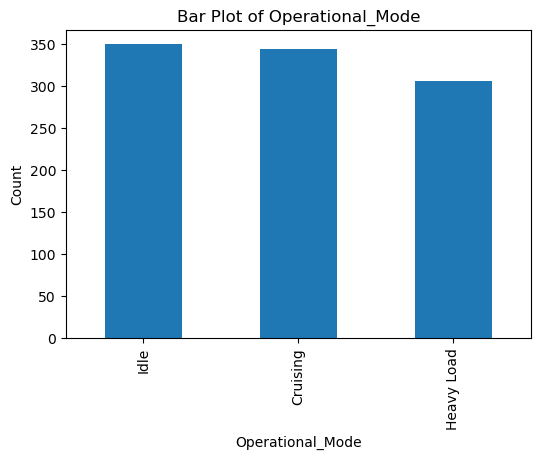

In [57]:
# Barplot for Categorical Attributes
categorical_cols = df.select_dtypes(include=['object'])
for col in categorical_cols.columns:
    
    plt.figure(figsize=(6,4))
    
    df[col].value_counts().plot(kind='bar')
    
    plt.title(f"Bar Plot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    
    plt.show()

In [62]:
import micropip

await micropip.install("seaborn")

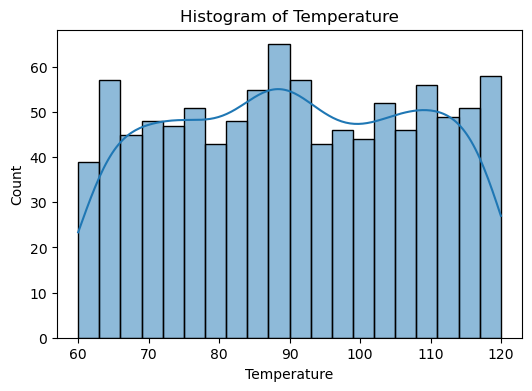

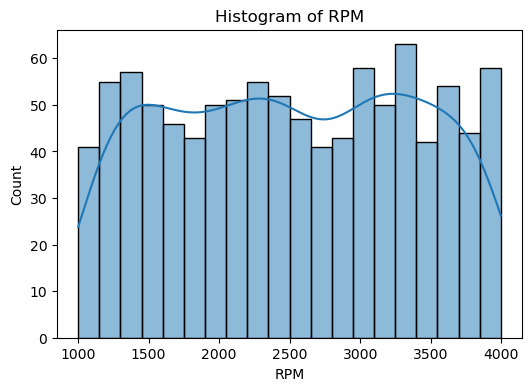

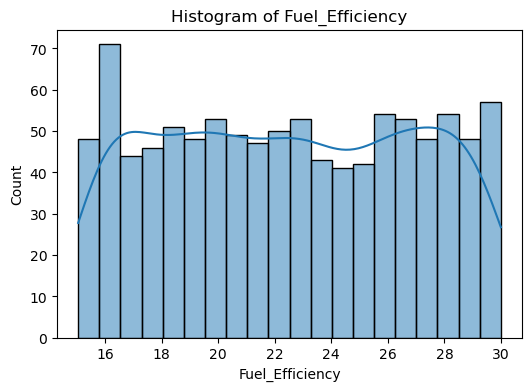

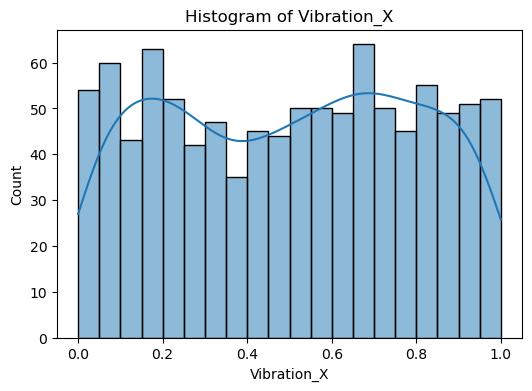

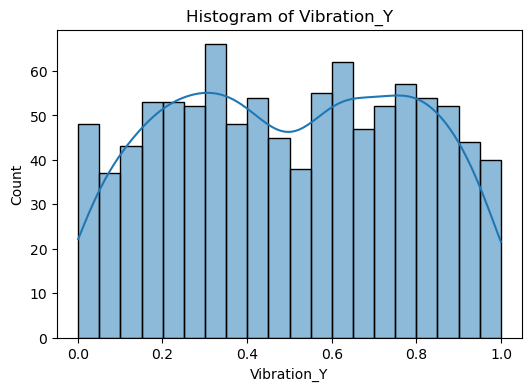

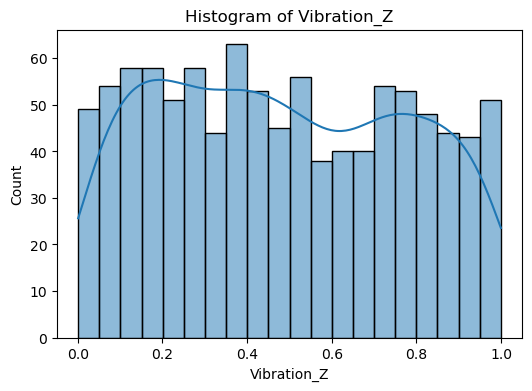

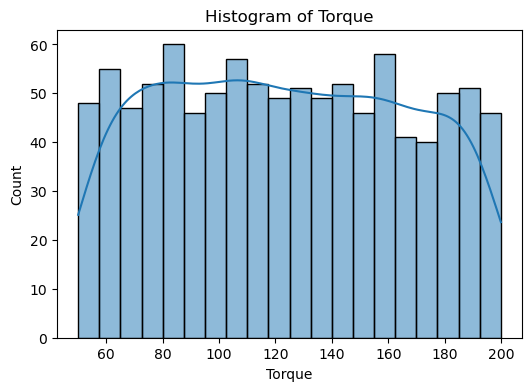

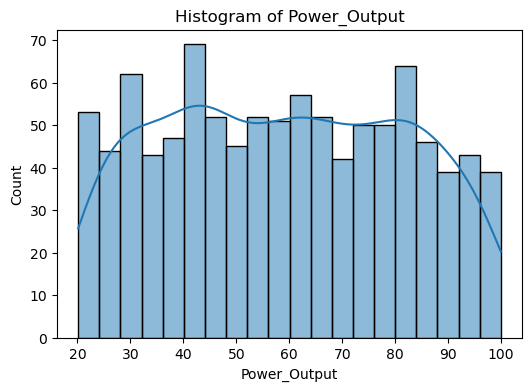

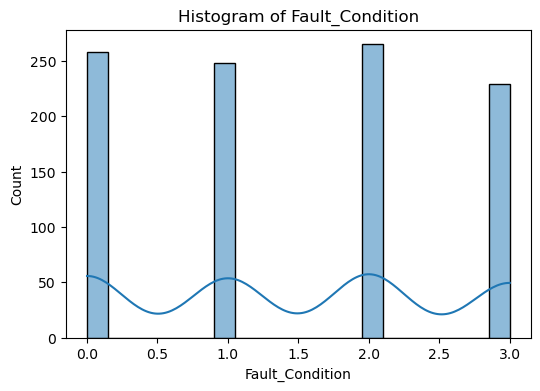

In [80]:
import seaborn as sns

for col in numeric_df.columns:
    
    plt.figure(figsize=(6,4))
    
    sns.histplot(
        numeric_df[col],
        bins=20,
        kde=True
    )
    
    plt.title(f"Histogram of {col}")
    
    plt.show()

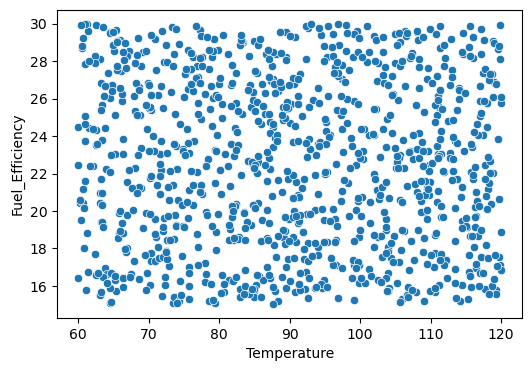

In [68]:
# Scatter Plot
plt.figure(figsize=(6,4))

sns.scatterplot(
    x='Temperature',
    y='Fuel_Efficiency',
    data=df
)
plt.show()

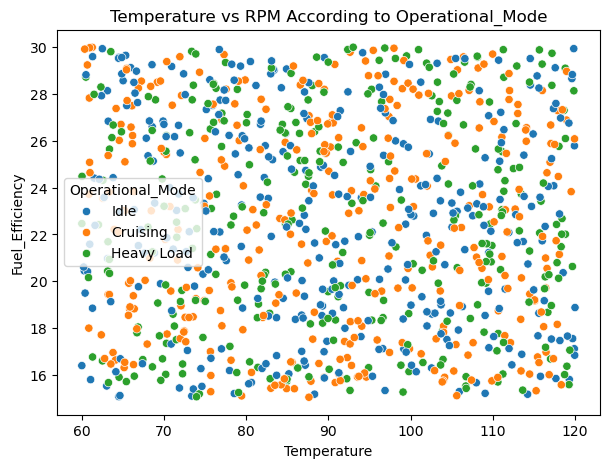

In [73]:
# Scatter Plot According to Class
plt.figure(figsize=(7,5))

sns.scatterplot(
    x='Temperature',
    y='Fuel_Efficiency',
    hue='Operational_Mode',
    data=df
)

plt.title("Temperature vs RPM According to Operational_Mode")

plt.show()

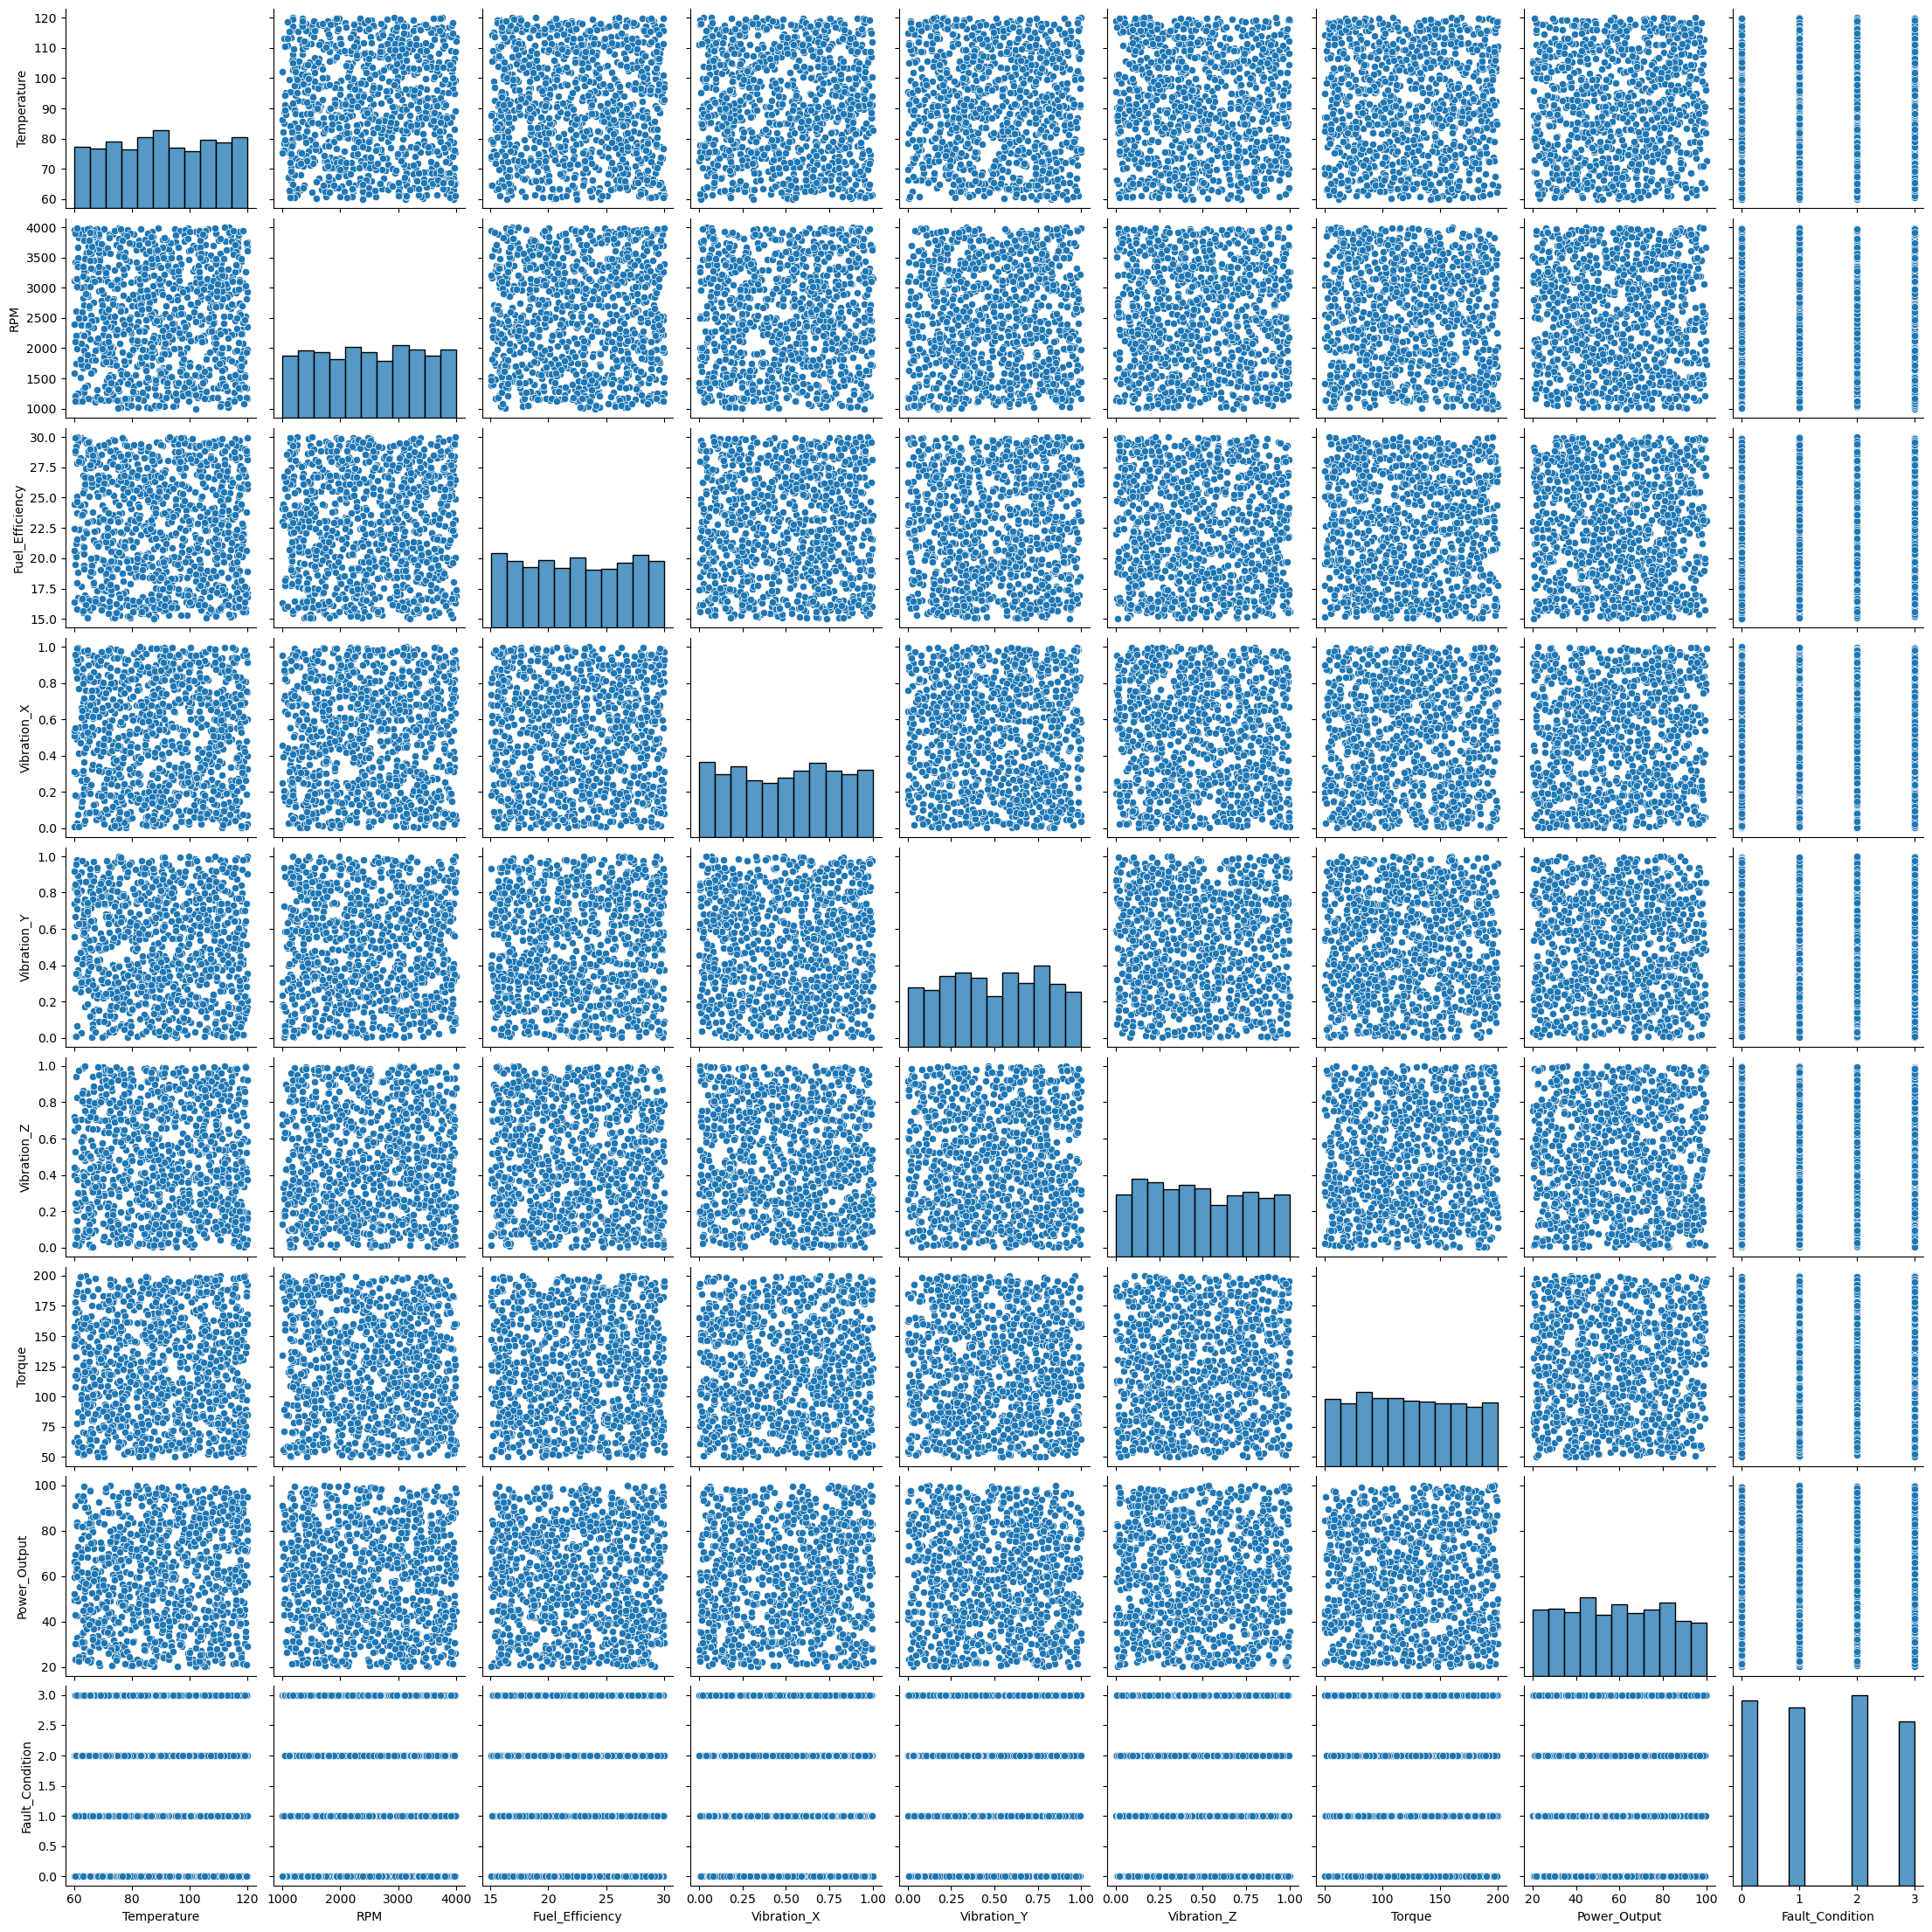

In [74]:
# Pair Plot

sns.pairplot(df)

plt.show()

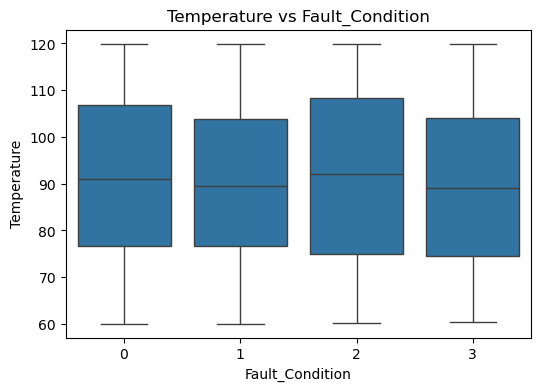

In [77]:
# Box Plot
plt.figure(figsize=(6,4))

sns.boxplot(
    x='Fault_Condition',
    y='Temperature',
    data=df
)

plt.title("Temperature vs Fault_Condition")

plt.show()

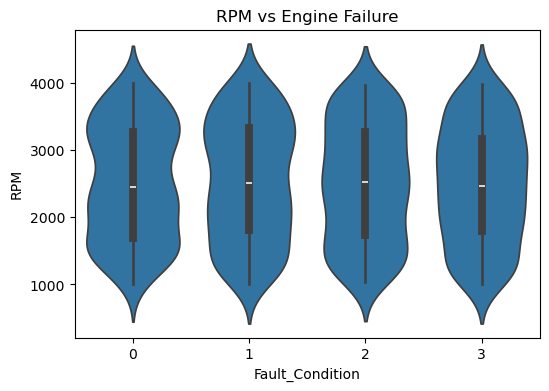

In [78]:
# Violin Plot
plt.figure(figsize=(6,4))

sns.violinplot(
    x='Fault_Condition',
    y='RPM',
    data=df
)

plt.title("RPM vs Engine Failure")

plt.show()

In [12]:
# Heat Map

import seaborn as sns
correlation = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

<class 'ModuleNotFoundError'>: No module named 'seaborn'

In [82]:
# FInd and Treat Null Values with suitable methodolgy
# Using sklearn Imputer
from sklearn.impute import SimpleImputer

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

categorical_cols = df.select_dtypes(include=['object']).columns

imputer = SimpleImputer(strategy='median')
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

In [83]:
# Null values for categorical variable
cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

In [84]:
# Drop feature less then 0.2 standard deviation
# Calculate standard deviation
std_values = numeric_df.std()

# Identify low variance features
low_std_features = std_values[std_values < 0.2]

print("Features with std < 0.2:")
print(low_std_features)

# Drop low variance features
df = df.drop(columns=low_std_features.index)

print("\nRemaining Columns:")
print(df.columns)

Features with std < 0.2:
Series([], dtype: float64)

Remaining Columns:
Index(['Temperature', 'RPM', 'Fuel_Efficiency', 'Vibration_X', 'Vibration_Y',
       'Vibration_Z', 'Torque', 'Power_Output', 'Fault_Condition',
       'Operational_Mode'],
      dtype='object')


In [86]:
# Standardization using StandardScaler
# Create scaler
from sklearn.preprocessing import StandardScaler
standard_scaler = StandardScaler()

# Standardize numeric columns
df_standardized = df.copy()

df_standardized[numeric_cols] = standard_scaler.fit_transform(
    df[numeric_cols]
)

print(df_standardized.head())

   Temperature       RPM  Fuel_Efficiency  Vibration_X  Vibration_Y  \
0    -1.750838  1.054660        -0.462546     1.270065    -1.767866   
1     1.287264  0.504477         0.134298     0.664744    -0.393409   
2     1.053356 -0.800765        -0.437697    -0.018666    -1.112743   
3     0.963118  0.251801         0.166529     1.648988     1.712006   
4     1.598676 -0.758650        -0.303578     0.713487    -1.428062   

   Vibration_Z    Torque  Power_Output  Fault_Condition Operational_Mode  
0     0.161848 -0.366098     -1.576714         0.483816             Idle  
1    -1.244519 -1.474558     -0.041760         1.388146         Cruising  
2     1.398800 -0.293588     -0.494966         0.483816         Cruising  
3    -0.052107 -1.076543     -0.655726         0.483816         Cruising  
4    -0.007294 -0.538731      0.967871         0.483816         Cruising  
